<a href="https://colab.research.google.com/github/Data-Vitor/fiap-data-science/blob/main/nemec-estatistica/cap05_ferramentas_estatisticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Capítulo 5 - Ferramentas Estastísticas Essencais**

In [1]:
print("Hello world!")

Hello world!


**Cálculo do Coeficiente de Pearson em Python**

In [4]:
import numpy as np
import pandas as pd

x = np.array([160, 165, 170, 175])
y = np.array([55,60,65,70])

#usando numpy
pearson_np = np.corrcoef(x, y)[0,1]
print(f'Pearson (Numpy): {pearson_np:.2f}')

#usando pandas

df = pd.DataFrame({'altura': x, 'peso':y})
pearson_pd = df['altura'].corr(df['peso'], method='pearson')
print(f'Pearson (Pandas): {pearson_pd:.2f}')



Pearson (Numpy): 1.00
Pearson (Pandas): 1.00


**Cálculo da correlação de Spearman em Python**

In [6]:
import numpy as np
from scipy.stats import spearmanr


x = np.array ([106,86,100,101,99])
y = np.array([7,0,27,50,28])
coef, p_value = spearmanr(x,y)
print(f'Coeficiente de Spearman:{coef:.2f}')

Coeficiente de Spearman:0.30


In [9]:
import pandas as pd

df = pd.DataFrame({
    'x':[106,86,100,101,99],
    'y':[7,0,27,50,28]
})

print(df['x'].corr(df['y'], method='spearman'))

0.3


**Cálculando o Coeficiente de Kendall Tau em Python**

In [10]:
import numpy as np
from scipy.stats import kendalltau

x = np.array([1,2,3])
y = np.array([3,2,1])

tau, p_value = kendalltau(x,y)
print(f'Coeficiente de Kendall Tau: {tau:.2f}')

Coeficiente de Kendall Tau: -1.00


In [13]:
import pandas as pd

df = pd.DataFrame({'X': [1,2,3], 'Y': [3,2,1]})
print(df['X'].corr(df['Y'], method='kendall'))

-1.0


**Codificação da matriz de correlação em Python**



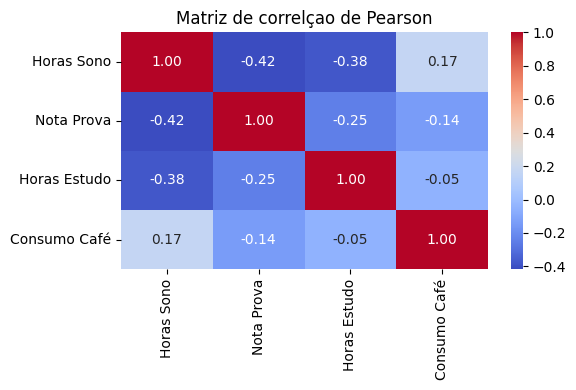

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#carregar o dataset externo

df = pd.read_csv('/content/drive/MyDrive/datasets/notas.csv')

#matriz de correlação de Pearson
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(method='pearson'), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Matriz de correlçao de Pearson')
plt.tight_layout()
plt.show()

**Calculando a Correlação Parcial em Python**

In [21]:
!pip install pingouin
import pandas as pd
import pingouin as pg
from scipy.stats import pearsonr

#dados ficticios simulando correlacoes conhecidas
df =pd.DataFrame({
    'X':[1,20,35,40,50,60,35,10],
    'Y':[2,22,75,45,55,59,72,30],
    'Z':[8,16,25,35,41,54,63,10]
})

#correlacoes simples
r_xy, _ = pearsonr(df['X'],df['Y'])
r_xz, _ = pearsonr(df['X'],df['Z'])
r_yz, _ = pearsonr(df['Y'],df['Z'])

print(f'Correlacao X,Y:{r_xy:.2f}')
print(f'Correlacao X,Z:{r_xz:.2f}')
print(f'Correlacao Y,Z:{r_yz:.2f}')

#calculo da correlaçao parcial entre X e Y, controlando Z

resultado = pg.partial_corr(data=df, x='X', y='Y', covar='Z', method='pearson' )
print(resultado)



Correlacao X,Y:0.76
Correlacao X,Z:0.81
Correlacao Y,Z:0.76
         n         r           CI95     p_val
pearson  8  0.371227  [-0.53, 0.88]  0.412297


In [30]:
import pandas as pd
import pingouin as pg
df = pd.read_csv('/content/drive/MyDrive/datasets/notas.csv')

resultado = pg.partial_corr(data=df, x='Nota Prova', y='Horas Estudo', covar=['Consumo Café', 'Horas Sono'], method='spearman')
print(resultado)

           n         r           CI95    p_val
spearman  20 -0.409964  [-0.74, 0.07]  0.09109


In [27]:
df = pd.read_csv('/content/drive/MyDrive/datasets/notas.csv')
list(df.columns)

['Horas Sono', 'Nota Prova', 'Horas Estudo', 'Consumo Café']

**Detecção univariada de outliers  pelo método IQR em Python**

In [32]:
import numpy as np
import pandas as pd

#50 e um outlier
dados = pd.Series([7,8,9,10,11,12,13,50])

q1 = dados.quantile(0.25)
q3 = dados.quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = dados[(dados < limite_inferior) | (dados > limite_superior)]
print(outliers)


7    50
dtype: int64


**Gerando  boxplot para detecção de outliers em Python**

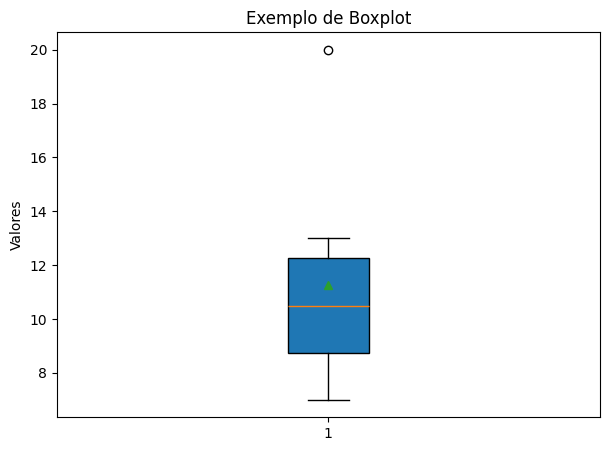

In [35]:
import matplotlib.pyplot as plt
import numpy as np

dados = np.array([7,8,9,10,11,12,13,20]) #20 é o outlier

plt.figure(figsize=(7,5))
plt.boxplot(dados, vert=True, patch_artist = True, showmeans=True)
plt.ylabel('Valores')
plt.title('Exemplo de Boxplot')
plt.show()

**Detectando Outliers através do Z-score**

In [44]:
import numpy as np
import pandas as pd

#20 e um possivel outlier

dados = np.array([7,8,9,10,11,12,13,20])
media = dados.mean()
desvio = dados.std()
zscore = (dados-media)/desvio
outliers = dados[np.abs(zscore)> 2]
print(outliers)

[20]


**Detectando outliers através da distancia de Mahalanobis**


In [51]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis

#dados de exemplo: idade e peso (ultima linha é um possivel outlier)
df = pd.DataFrame({
    'idade':[22,35,42,55,60,37,28,45,39,80],
    'peso':[65,80,77,90,85,78,68,82,75,100]

})

#calculo do centroide (media)
mu = df.mean().values

#matriz de covarianca
s = np.cov(df.values, rowvar=False)
s_inv = np.linalg.inv(s)

#calculando Mahalanobis para cada ponto

df['mahalanobis'] = df.apply(lambda row: mahalanobis(row, mu, s_inv), axis=1)
print(df)

   idade  peso  mahalanobis
0     22    65     1.496230
1     35    80     1.819645
2     42    77     0.560832
3     55    90     1.399208
4     60    85     1.602856
5     37    78     0.833390
6     28    68     1.286781
7     45    82     0.519792
8     39    75     0.706616
9     80   100     2.118700
